<a href="https://colab.research.google.com/github/shruti06754/student-performance-predictor/blob/main/student_performance_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Create a sample dataset

In [4]:
np.random.seed(42)
students = 200
data = pd.DataFrame({
    "Study Hours": np.random.randint(1, 10, students),
    "Attendance": np.random.randint(50, 101, students),
    "Previous Score": np.random.randint(40, 96, students),
    "Assignments Score": np.random.randint(40, 101, students)
})

data["Final Marks"] = (
    data["Study Hours"] * 2
    + data["Attendance"] * 0.2
    + data["Previous Score"] * 0.4
    + data["Assignments Score"] * 0.2
    + np.random.randint(-5, 6, students)
)

data["Final Marks"] = data["Final Marks"].clip(0, 100)
data.head()

,Study Hours,Attendance,Previous Score,Assignments Score,Final Marks
0,7,50,94,68,74.2
1,4,60,65,82,63.4
2,8,77,76,50,70.8
3,5,74,65,57,61.2
4,7,99,92,86,86.8


# Check the data

In [5]:
print("Number of rows:", len(data))
print("\nMissing values:")
print(data.isnull().sum())
print("\nDuplicate rows:", data.duplicated().sum())

Number of rows: 200

Missing values:
Study Hours          0
Attendance           0
Previous Score       0
Assignments Score    0
Final Marks          0
dtype: int64

Duplicate rows: 0


# Data pre-processing

In [6]:
data = data.drop_duplicates()

data = data.fillna(data.mean(numeric_only=True))

print("Data preprocessing completed.")

Data preprocessing completed.


# EDA-Study hours VS Final marks

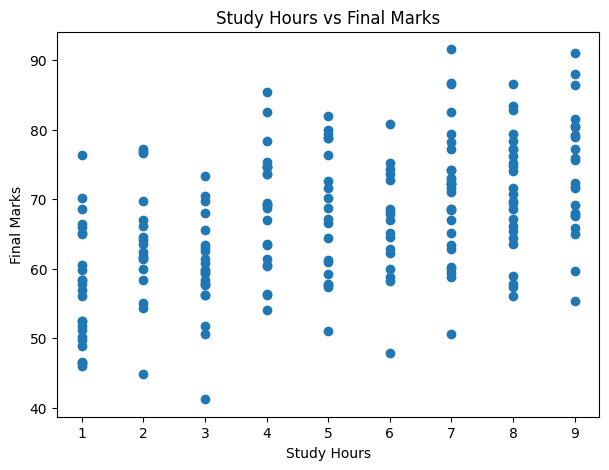

In [7]:
plt.figure(figsize=(7, 5))

plt.scatter(
    data["Study Hours"],
    data["Final Marks"]
)

plt.xlabel("Study Hours")
plt.ylabel("Final Marks")
plt.title("Study Hours vs Final Marks")

plt.show()

# EDA-Attendance VS Final marks

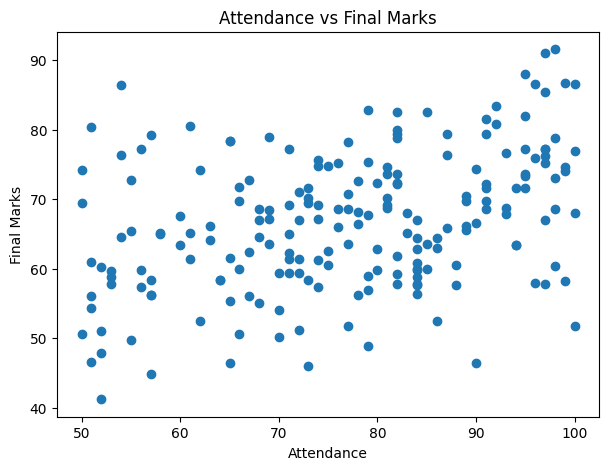

In [8]:
plt.figure(figsize=(7, 5))

plt.scatter(
    data["Attendance"],
    data["Final Marks"]
)

plt.xlabel("Attendance")
plt.ylabel("Final Marks")
plt.title("Attendance vs Final Marks")

plt.show()

# Distribution of marks

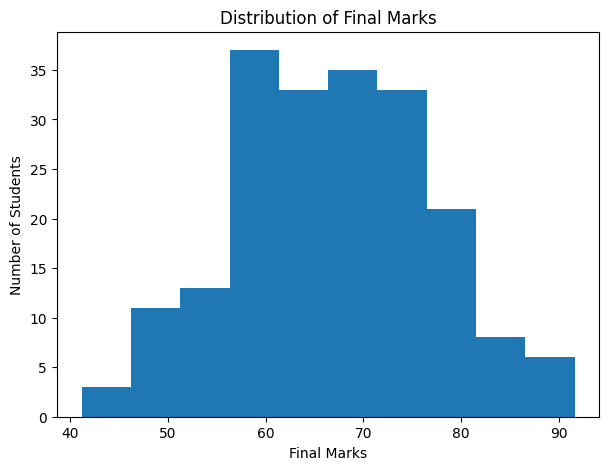

In [9]:
plt.figure(figsize=(7, 5))

plt.hist(data["Final Marks"], bins=10)

plt.xlabel("Final Marks")
plt.ylabel("Number of Students")
plt.title("Distribution of Final Marks")

plt.show()

# Select input and output

In [10]:
X = data[
    [
        "Study Hours",
        "Attendance",
        "Previous Score",
        "Assignments Score"
    ]
]

y = data["Final Marks"]

# Split the data

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", len(X_train))
print("Testing data:", len(X_test))

Training data: 160
Testing data: 40


# Create the Random Forest model

In [12]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


# Make predictions

In [13]:
y_pred = model.predict(X_test)

print("Predictions completed!")

Predictions completed!


# Compare actual and predicted marks

In [14]:
result = pd.DataFrame({
    "Actual Marks": y_test.values,
    "Predicted Marks": y_pred
})

print(result.head(10))

   Actual Marks  Predicted Marks
0          51.8           57.278
1          54.4           61.026
2          58.4           61.446
3          51.8           52.994
4          46.6           50.814
5          72.8           69.216
6          65.0           71.352
7          59.4           57.868
8          58.4           64.250
9          56.2           62.210


# Evaluate the model

In [15]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("MAE:", round(mae, 2))
print("MSE:", round(mse, 2))
print("R2 Score:", round(r2, 2))

MAE: 3.7
MSE: 19.88
R2 Score: 0.81


# Actual vs Predicted graph

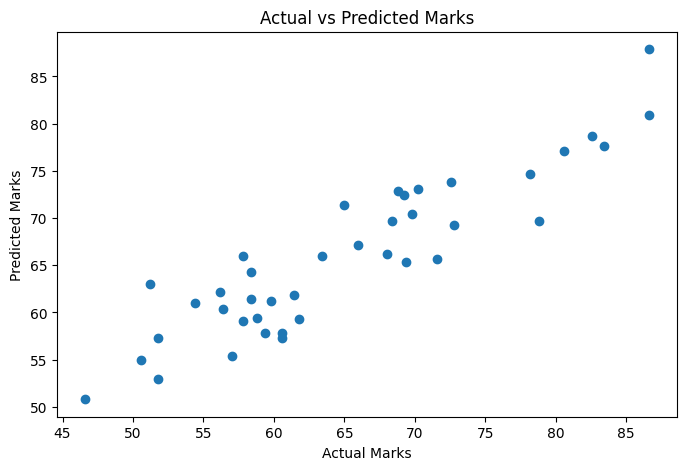

In [16]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted Marks")

plt.show()

# Predict marks for a new student

In [17]:
new_student = pd.DataFrame({
    "Study Hours": [7],
    "Attendance": [85],
    "Previous Score": [75],
    "Assignments Score": [80]
})

prediction = model.predict(new_student)

print("Predicted Final Marks:", round(prediction[0], 2))

Predicted Final Marks: 74.96


# Save your results

In [18]:
result.to_csv(
    "student_predictions.csv",
    index=False
)

print("Results saved successfully!")

Results saved successfully!
